##Ahmed Raza


**Introduction to Machine Learning & AI**

**MBAN-1**

# **IBM HR Analytics Employee Attrition & Performance: Predict whether an employee will leave (Attrition = Yes/No)**

---

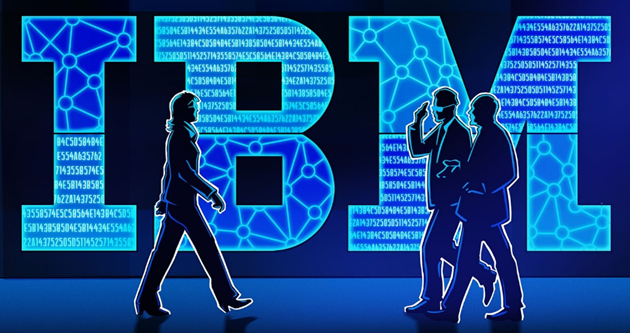
## **Data Source**:
'https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset'

### **Business Objective**

Predict employee attrition and identify key contributing factors to develop targeted retention strategies.

### **Why This Analysis Matters:**

- Reduce replacement costs (estimated at 1-2× annual salary per employee)
- Preserve institutional knowledge and productivity
- Improve employee satisfaction and company culture

### **Key Stakeholders:**

- HR Department: Needs actionable retention strategies
- Department Managers: Need to identify at-risk employees
- Executive Leadership: Need ROI justification for retention programs

### **Success Metrics:**

Predictive performance: Accuracy, precision, recall, F1-score, AUC-ROC
Business impact: Estimated cost savings from reduced attrition

### **Assumptions/Constraints:**

Historical patterns will remain relevant for future predictions
All major attrition factors are captured in available data.

# **Part 1: Data input and Cleaning**


## **2. Data Understanding**

- Load and inspect the IBM HR Analytics Attrition dataset
- Feature explanation from business perspective:
    - Demographic factors: Age, Gender, MaritalStatus
    - Job-related factors: Department, JobRole, JobLevel
    - Compensation factors: MonthlyIncome, StockOptionLevel
    - Satisfaction metrics: JobSatisfaction, EnvironmentSatisfaction
    - Career development: YearsAtCompany, TrainingTimesLastYear


## Import Dataset and Libraries

In [ ]:
# Import necessary libraries

# Data manipulation and analysis
import pandas as pd

# Numerical computation operations
import numpy as np

# Plotting and data visualization
import matplotlib.pyplot as plt

# Statistical data visualization
import seaborn as sns

# Splitting data and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Scaling and encoding features
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest Classifier (Bagging)
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Extreme Gradient Boosting (Boosting Algorithm)
from xgboost import XGBClassifier

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

**Understand Data Strucuture and Format**

In [ ]:
# Display basic information about the dataset

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of employees who left: {df['Attrition'].value_counts()['Yes']}")
print(f"Attrition rate: {df['Attrition'].value_counts()['Yes']/len(df):.2%}")

# Display the first few rows

print("\nFirst few rows of the dataset:")
df.head()

# Get column information

print("\nColumn information:")
df.info()

Dataset shape: (1470, 35)

Number of employees who left: 237
Attrition rate: 16.12%

First few rows of the dataset:

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object


**Data Statistics and Handling Missing Values**

In [ ]:
# Check for missing values

print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
# Summary statistics for numerical features

print("\nSummary statistics for numerical features:")
df.describe()


Summary statistics for numerical features:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Categorical Features and Business Explanations

In [ ]:
# Examine categorical features
print("\nUnique values in categorical features:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# Business explanation of features
feature_explanation = {
    'Age': 'Employee\'s age in years',
    'Attrition': 'Whether the employee left the company (Yes) or not (No)',
    'BusinessTravel': 'Frequency of business travel',
    'DailyRate': 'Daily rate of pay',
    'Department': 'Employee\'s department',
    'DistanceFromHome': 'Distance from home to work (in miles)',
    'Education': 'Level of education (1-5 scale)',
    'EducationField': 'Field of education',
    'EmployeeCount': 'Count of employees (always 1, redundant feature)',
    'EmployeeNumber': 'Unique employee identifier',
    'EnvironmentSatisfaction': 'Satisfaction with work environment (1-4 scale)',
    'Gender': 'Employee\'s gender',
    'HourlyRate': 'Hourly rate of pay',
    'JobInvolvement': 'Job involvement rating (1-4 scale)',
    'JobLevel': 'Job level within the organization (1-5 scale)',
    'JobRole': 'Job role/title',
    'JobSatisfaction': 'Job satisfaction rating (1-4 scale)',
    'MaritalStatus': 'Marital status (Single, Married, Divorced)',
    'MonthlyIncome': 'Monthly income in dollars',
    'MonthlyRate': 'Monthly rate',
    'NumCompaniesWorked': 'Number of previous companies worked for',
    'Over18': 'Whether employee is over 18 (all are "Y", redundant feature)',
    'OverTime': 'Whether employee works overtime',
    'PercentSalaryHike': 'Percent increase in salary last year',
    'PerformanceRating': 'Performance rating (1-4 scale)',
    'RelationshipSatisfaction': 'Relationship satisfaction rating (1-4 scale)',
    'StandardHours': 'Standard hours (always 80, redundant feature)',
    'StockOptionLevel': 'Stock option level (0-3 scale)',
    'TotalWorkingYears': 'Total years of working experience',
    'TrainingTimesLastYear': 'Number of training sessions attended last year',
    'WorkLifeBalance': 'Work-life balance rating (1-4 scale)',
    'YearsAtCompany': 'Years at the company',
    'YearsInCurrentRole': 'Years in current role',
    'YearsSinceLastPromotion': 'Years since last promotion',
    'YearsWithCurrManager': 'Years with current manager'
}

# Display feature explanations in a DataFrame
pd.DataFrame([feature_explanation], index=['Business Meaning']).T


Unique values in categorical features:
Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
Over18: ['Y']
OverTime: ['Yes' 'No']


,Business Meaning
Age,Employee's age in years
Attrition,Whether the employee left the company (Yes) or...
BusinessTravel,Frequency of business travel
DailyRate,Daily rate of pay
Department,Employee's department
DistanceFromHome,Distance from home to work (in miles)
Education,Level of education (1-5 scale)
EducationField,Field of education
EmployeeCount,"Count of employees (always 1, redundant feature)"
EmployeeNumber,Unique employee identifier


# **Part 2: Data Enhancement & Preprocessing**

- Drop Redundant Features  

- Correlation of Numerical Features  

- Categortical Features

- Training and Testing Sets

In [ ]:
# Identify and drop redundant features

redundant_features = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_cleaned = df.drop(redundant_features, axis=1)

In [ ]:
# Convert 'Attrition' to binary (1 for 'Yes', 0 for 'No')

df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})

In [ ]:
# Inspect correlation of numerical features with Attrition

numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_with_attrition = df_cleaned[numerical_features].corrwith(df_cleaned['Attrition']).sort_values(ascending=False)
print("Correlation of numerical features with Attrition:")
print(correlation_with_attrition)

Correlation of numerical features with Attrition:
Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
dtype: float64


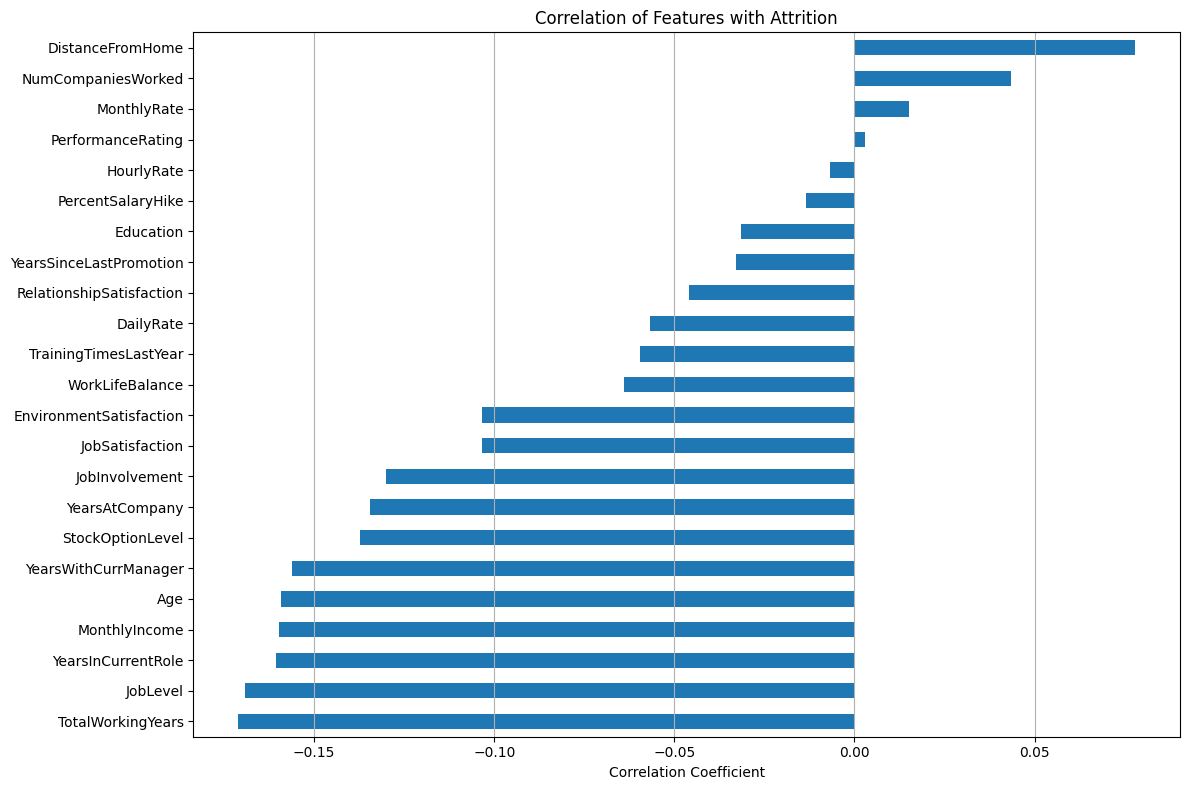

In [ ]:
# Visualize correlation with Attrition
plt.figure(figsize=(12, 8))
correlation_with_attrition.drop('Attrition').sort_values().plot(kind='barh')
plt.title('Correlation of Features with Attrition')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

This bar chart shows the correlation of numerical features with employee attrition. Features on the left (negative correlation) like TotalWorkingYears, JobLevel, MonthlyIncome, and Age indicate that higher values reduce the chance of attrition. Features on the right (positive correlation) like DistanceFromHome and NumCompaniesWorked indicate that higher values increase the risk of attrition.

## Identify categorical features

We identified all categorical (text-based) columns in the dataset using `select_dtypes(include=['object'])`, stores them in a list called `categorical_features`, and prints it. These features must be encoded into numerical format, such as with One-Hot Encoding, before they can be used in machine learning models.

In [ ]:
# Identify categorical features

categorical_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical features:", categorical_features)


Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [ ]:
# Function to create dummy variables for categorical features

def create_dummies(df, categorical_cols):
    """Create dummy variables for categorical features"""
    df_with_dummies = df.copy()
    for col in categorical_cols:
        dummies = pd.get_dummies(df_with_dummies[col], prefix=col, drop_first=True)
        df_with_dummies = pd.concat([df_with_dummies, dummies], axis=1)
        df_with_dummies.drop(col, axis=1, inplace=True)
    return df_with_dummies

In [ ]:
# Create dummy variables

df_encoded = create_dummies(df_cleaned, categorical_features)
print("\nDataset shape after encoding:", df_encoded.shape)



Dataset shape after encoding: (1470, 45)


In [ ]:
# Check for any remaining issues in the processed dataset

print("\nMissing values after preprocessing:")
print(df_encoded.isnull().sum().sum())


Missing values after preprocessing:
0


In [ ]:
# Split the data into features and target

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

## Split: Training and Testing Sets

This code splits the dataset into training and testing sets using `train_test_split` with 80% data for training and 20% for testing. Then, it applies feature scaling using `StandardScaler` to normalize the features. Finally, it prints the shape of the training and testing sets for verification.

In [ ]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (1176, 44)
Testing set shape: (294, 44)


# **Part 3: Exploratory Data Analysis**

- Distribution and Variables and Coorelation Analysis

## Distribution of Variables and Correlation Analysis

**Employee Attrition:**

The majority of employees did not leave the company (Attrition = No), while a smaller portion left the company (Attrition = Yes). This indicates that the data is imbalanced, which should be considered during model building and evaluation.

**Distribution of employees based on Attrition:**

Most employees who left the company (Attrition = Yes) are between 25 to 35 years old. Younger employees have a higher attrition rate, while older employees, especially above 40, tend to stay longer in the company.


**Attrition Rates by Department:**

 The Sales department has the highest attrition rate, followed by Human Resources. Research & Development has the lowest attrition rate. This suggests employees in Sales and HR are more likely to leave, highlighting areas where retention strategies should be prioritized.


**Attrition Rate by Job Role:**

This bar chart shows the attrition rate across different job roles. Sales Representatives have the highest attrition rate, indicating that employees in sales positions are more likely to leave the company. Roles like Manager, Research Director, and Manufacturing Director have the lowest attrition rates.


**Correlation Heatmap of Key Features:**

This heatmap visualizes the correlation between important numerical features. Age, Monthly Income, Total Working Years, and Job Level show a strong negative correlation with attrition, meaning higher values reduce attrition. Features like YearsAtCompany and YearsWithCurrManager have a weaker but noticeable negative correlation.

**Attrition Rate by Overtime:**

This bar chart shows that employees working overtime have a significantly higher attrition rate compared to those who do not. The attrition rate for employees with overtime is above 30%, while for non-overtime workers it is around 10%, highlighting overtime as a major factor influencing attrition.

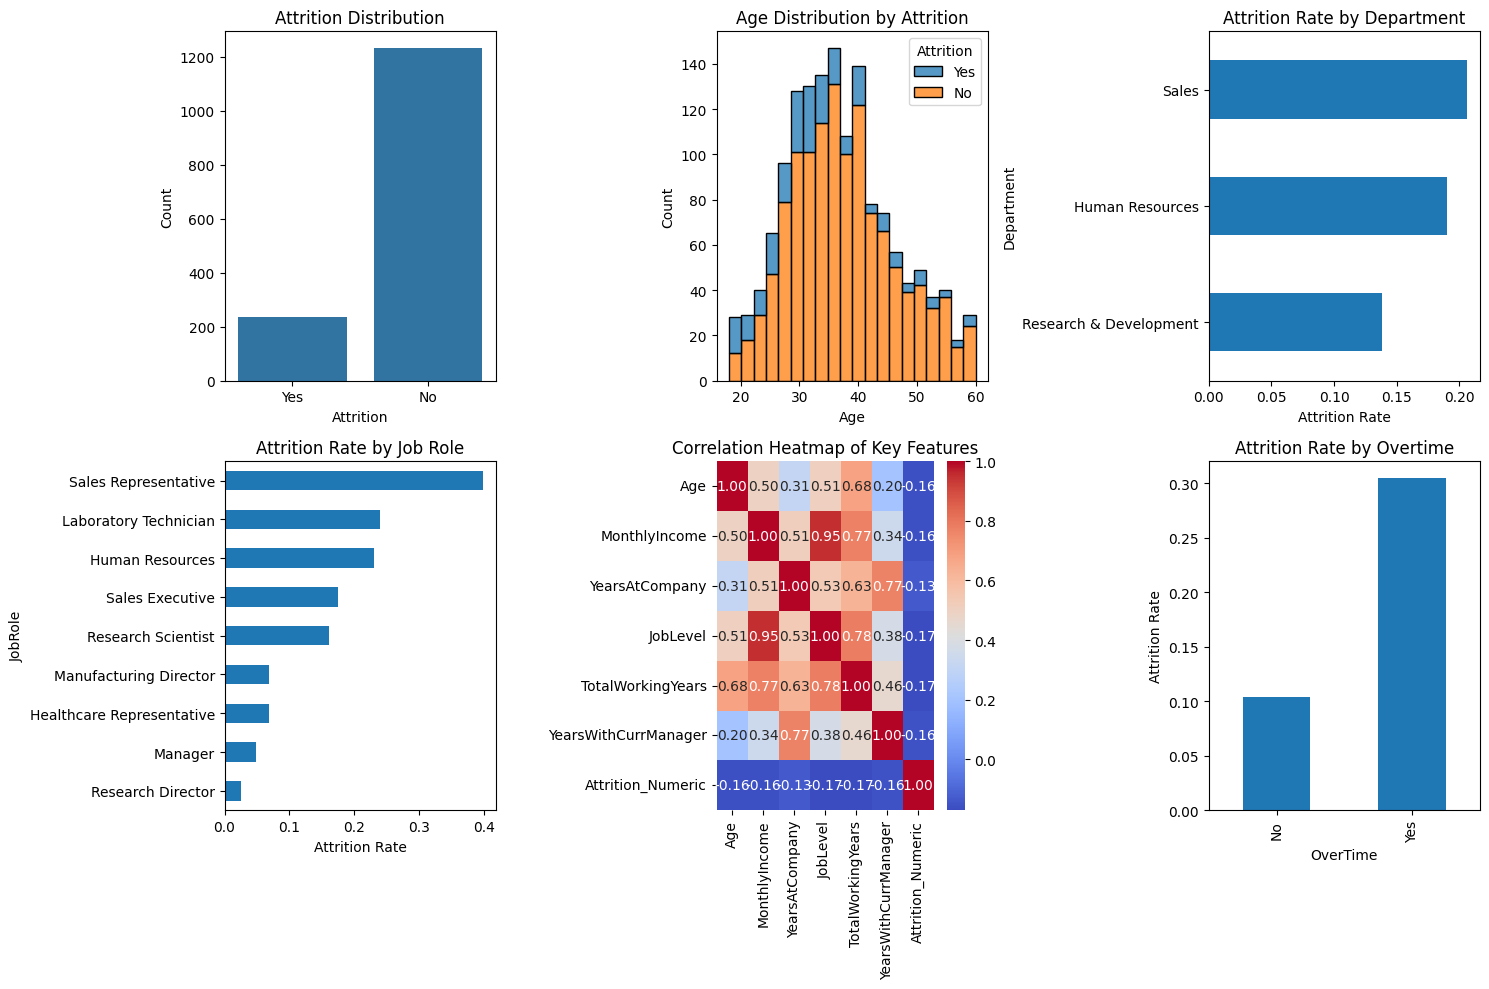

In [ ]:
# Set up figure size for plots
plt.figure(figsize=(15, 10))

# 1. Attrition distribution
plt.subplot(2, 3, 1)
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.ylabel('Count')

# 2. Age distribution by attrition
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', bins=20)
plt.title('Age Distribution by Attrition')

# 3. Attrition by Department
plt.subplot(2, 3, 3)
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
dept_attrition['Yes'].sort_values().plot(kind='barh')
plt.title('Attrition Rate by Department')
plt.xlabel('Attrition Rate')

# 4. Attrition by JobRole
plt.subplot(2, 3, 4)
role_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
role_attrition['Yes'].sort_values().plot(kind='barh')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate')

# 5. Correlation heatmap for key metrics
plt.subplot(2, 3, 5)
important_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel',
                      'TotalWorkingYears', 'YearsWithCurrManager', 'Attrition']
# Convert 'Attrition' to numeric before calculating correlation
df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})
important_features_numeric = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel',
                              'TotalWorkingYears', 'YearsWithCurrManager', 'Attrition_Numeric']
corr_matrix = df[important_features_numeric].corr()  # Calculate correlation on numeric features
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Features')

# 6. Attrition by Overtime
plt.subplot(2, 3, 6)
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()
overtime_attrition['Yes'].plot(kind='bar')
plt.title('Attrition Rate by Overtime')
plt.ylabel('Attrition Rate')

plt.tight_layout()
plt.show()

## Hypothese Driven Analysis

- Lower job satisfaction correlates with higher attrition
- Distance from home impacts retention
- Compensation level is inversely related to attrition
- Work-life balance scores predict attrition likelihood
- Career growth opportunities affect retention


**Use of `scipy.stats`:**

- `scipy.stats` provides a large collection of statistical functions and hypothesis testing tools.
- It is commonly used for:
  - Comparing groups
  - Validating assumptions
  - Testing relationships between variables

In [ ]:
# Import statistical testing packages
from scipy.stats import chi2_contingency, ttest_ind

**# Hypothesis 1: Lower Job Satisfaction Correlates with Higher Attrition**


The bar chart shows that employees with lower job satisfaction (scale = 1) have the highest attrition rate, while those with higher job satisfaction (scale = 4) have the lowest attrition rate.  

The Chi-square test result shows a p-value of 0.0006 (less than 0.05), meaning we reject the null hypothesis. This indicates a statistically significant relationship between job satisfaction and attrition — lower job satisfaction leads to higher employee attrition.


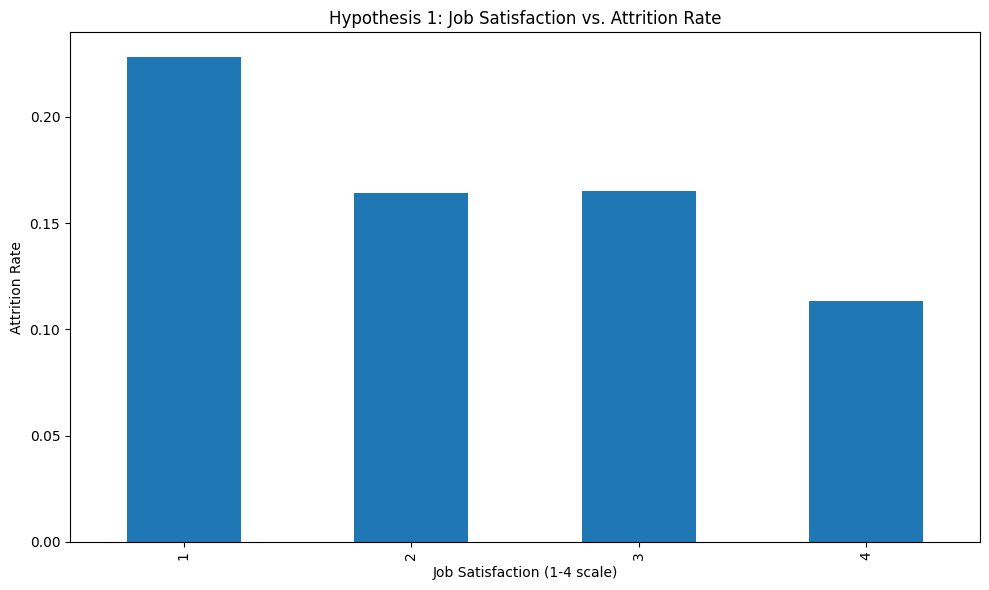

In [ ]:
# Hypothesis 1: Lower job satisfaction correlates with higher attrition

plt.figure(figsize=(10, 6))
job_sat_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack()
job_sat_attrition['Yes'].plot(kind='bar')
plt.title('Hypothesis 1: Job Satisfaction vs. Attrition Rate')
plt.xlabel('Job Satisfaction (1-4 scale)')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test for Hypothesis 1

job_sat_contingency = pd.crosstab(df['JobSatisfaction'], df['Attrition'])
chi2, p, dof, expected = chi2_contingency(job_sat_contingency)
print(f"Hypothesis 1 - Chi-square test: chi2 = {chi2:.2f}, p-value = {p:.4f}")
print(f"Conclusion: {'Reject null hypothesis' if p < 0.05 else 'Fail to reject null hypothesis'}")

Hypothesis 1 - Chi-square test: chi2 = 17.51, p-value = 0.0006
Conclusion: Reject null hypothesis


**Hypothesis 2: Distance from Home Impacts Retention**

The bar chart shows that employee attrition rates increase as the distance from home increases. Those living more than 15 miles away show notably higher attrition.

The independent t-test result (t = 2.99, p-value = 0.0028) is statistically significant (p < 0.05), so we **reject the null hypothesis**. This confirms a meaningful difference in distance from home between employees who leave and those who stay. Greater commuting distance is significantly associated with higher attrition.

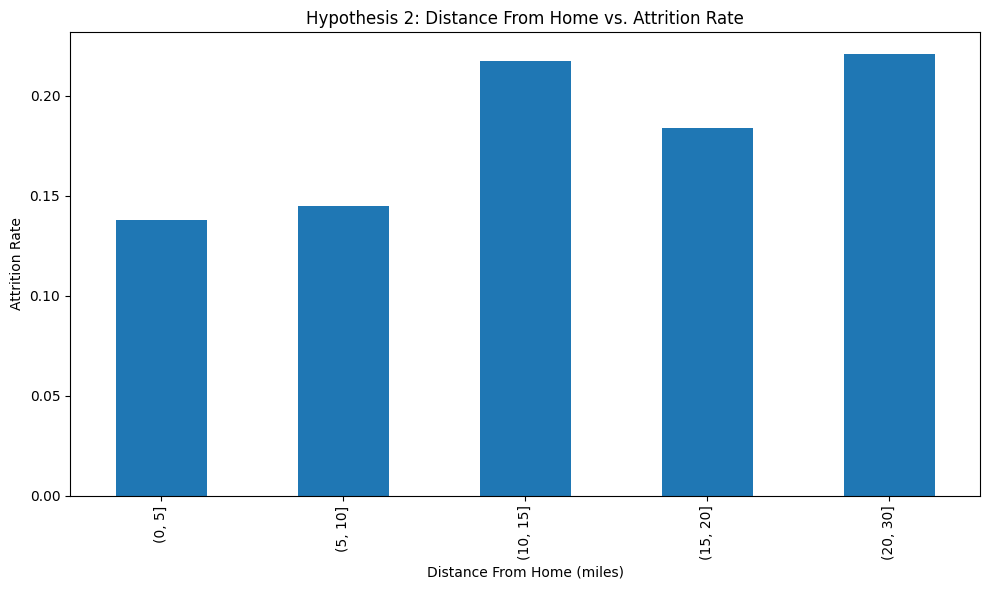

In [ ]:
# Hypothesis 2: Distance from home impacts retention

plt.figure(figsize=(10, 6))
distance_bins = [0, 5, 10, 15, 20, 30]
df['DistanceBin'] = pd.cut(df['DistanceFromHome'], bins=distance_bins)
distance_attrition = df.groupby('DistanceBin')['Attrition'].value_counts(normalize=True).unstack()
distance_attrition['Yes'].plot(kind='bar')
plt.title('Hypothesis 2: Distance From Home vs. Attrition Rate')
plt.xlabel('Distance From Home (miles)')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test for Hypothesis 2

attrition_yes = df[df['Attrition'] == 'Yes']['DistanceFromHome']
attrition_no = df[df['Attrition'] == 'No']['DistanceFromHome']
t_stat, p_val = ttest_ind(attrition_yes, attrition_no)
print(f"Hypothesis 2 - Independent t-test: t = {t_stat:.2f}, p-value = {p_val:.4f}")
print(f"Conclusion: {'Reject null hypothesis' if p_val < 0.05 else 'Fail to reject null hypothesis'}")

Hypothesis 2 - Independent t-test: t = 2.99, p-value = 0.0028
Conclusion: Reject null hypothesis


**Hypothesis 3: Compensation level is inversely related to attrition**

The bar chart shows that employees with lower monthly income (0-2000 USD) have the highest attrition rate. As monthly income increases, the attrition rate decreases significantly, indicating income is a key factor in retention.

The independent t-test result (t = -6.20, p-value = 0.0000) shows a statistically significant difference (p < 0.05). Therefore, we reject the null hypothesis, confirming that lower monthly income is strongly associated with higher employee attrition in this dataset.

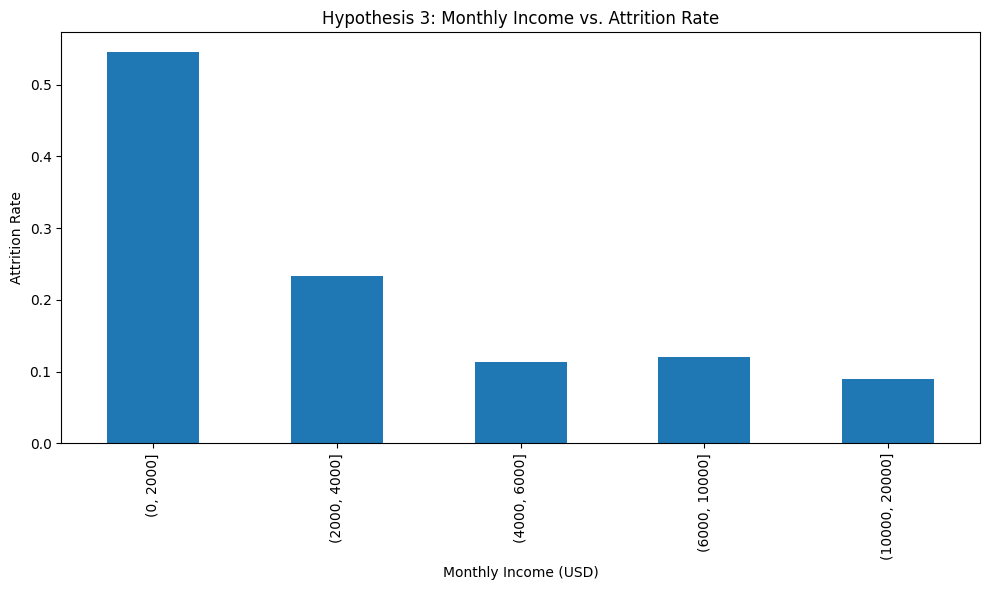

In [ ]:
# Hypothesis 3: Compensation level is inversely related to attrition

plt.figure(figsize=(10, 6))
income_bins = [0, 2000, 4000, 6000, 10000, 20000]
df['IncomeBin'] = pd.cut(df['MonthlyIncome'], bins=income_bins)
income_attrition = df.groupby('IncomeBin')['Attrition'].value_counts(normalize=True).unstack()
income_attrition['Yes'].plot(kind='bar')
plt.title('Hypothesis 3: Monthly Income vs. Attrition Rate')
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test for Hypothesis 3

attrition_yes = df[df['Attrition'] == 'Yes']['MonthlyIncome']
attrition_no = df[df['Attrition'] == 'No']['MonthlyIncome']
t_stat, p_val = ttest_ind(attrition_yes, attrition_no)
print(f"Hypothesis 3 - Independent t-test: t = {t_stat:.2f}, p-value = {p_val:.4f}")
print(f"Conclusion: {'Reject null hypothesis' if p_val < 0.05 else 'Fail to reject null hypothesis'}")

Hypothesis 3 - Independent t-test: t = -6.20, p-value = 0.0000
Conclusion: Reject null hypothesis


**Hypothesis 4: Work-life balance scores predict attrition likelihood**

Employees with a poor work-life balance rating of 1 have the highest attrition rate (over 30%), while those with better ratings (2–4) have lower attrition.
  
Chi-square test: χ² = 16.33, **p-value = 0.0010  
Since p < 0.05, we **reject the null hypothesis**. This means there's a statistically significant relationship between work-life balance and attrition. Poor work-life balance increases employee turnover.

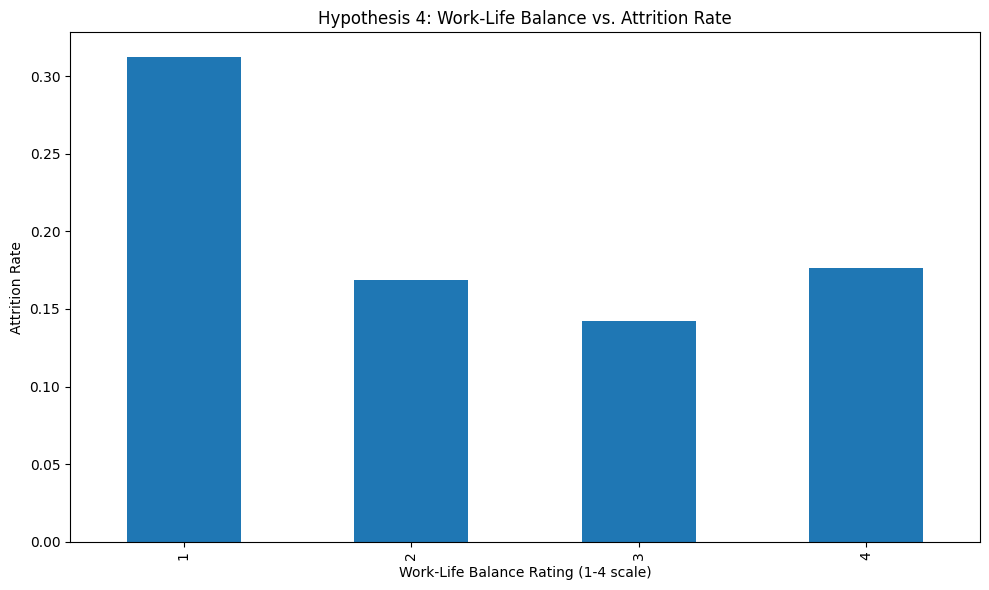

In [ ]:
# Hypothesis 4: Work-life balance scores predict attrition likelihood

plt.figure(figsize=(10, 6))
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack()
wlb_attrition['Yes'].plot(kind='bar')
plt.title('Hypothesis 4: Work-Life Balance vs. Attrition Rate')
plt.xlabel('Work-Life Balance Rating (1-4 scale)')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical test for Hypothesis 4

wlb_contingency = pd.crosstab(df['WorkLifeBalance'], df['Attrition'])
chi2, p, dof, expected = chi2_contingency(wlb_contingency)
print(f"Hypothesis 4 - Chi-square test: chi2 = {chi2:.2f}, p-value = {p:.4f}")
print(f"Conclusion: {'Reject null hypothesis' if p < 0.05 else 'Fail to reject null hypothesis'}")

Hypothesis 4 - Chi-square test: chi2 = 16.33, p-value = 0.0010
Conclusion: Reject null hypothesis


**Hypothesis 5: Career growth opportunities affect retention**

Attrition rates vary across promotion intervals but do not follow a clear trend. Surprisingly, employees not promoted in 5–10 years have the highest attrition, while those not promoted in 3–5 years have the lowest.

Independent t-test: t = -1.27, **p-value = 0.2058

Since p > 0.05, we **fail to reject the null hypothesis**. There is **no statistically significant** relationship between years since last promotion and attrition.

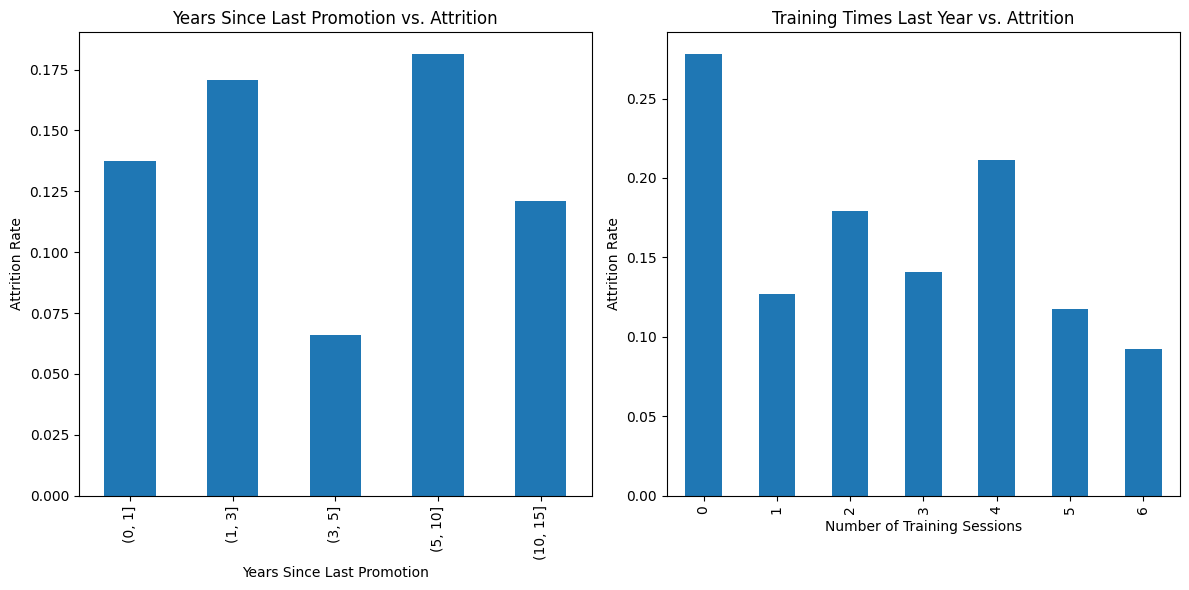

In [ ]:
# Hypothesis 5: Career growth opportunities affect retention

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
yslp_bins = [0, 1, 3, 5, 10, 15]
df['YSLPBin'] = pd.cut(df['YearsSinceLastPromotion'], bins=yslp_bins)
yslp_attrition = df.groupby('YSLPBin')['Attrition'].value_counts(normalize=True).unstack()
yslp_attrition['Yes'].plot(kind='bar')
plt.title('Years Since Last Promotion vs. Attrition')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate')

plt.subplot(1, 2, 2)
training_attrition = df.groupby('TrainingTimesLastYear')['Attrition'].value_counts(normalize=True).unstack()
training_attrition['Yes'].plot(kind='bar')
plt.title('Training Times Last Year vs. Attrition')
plt.xlabel('Number of Training Sessions')
plt.ylabel('Attrition Rate')

plt.tight_layout()
plt.show()

In [ ]:
# Statistical test for Years Since Last Promotion

attrition_yes = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion']
attrition_no = df[df['Attrition'] == 'No']['YearsSinceLastPromotion']
t_stat, p_val = ttest_ind(attrition_yes, attrition_no)
print(f"Hypothesis 5a - Independent t-test (YSLP): t = {t_stat:.2f}, p-value = {p_val:.4f}")
print(f"Conclusion: {'Reject null hypothesis' if p_val < 0.05 else 'Fail to reject null hypothesis'}")

Hypothesis 5a - Independent t-test (YSLP): t = -1.27, p-value = 0.2058
Conclusion: Fail to reject null hypothesis


# **Part 4: Predictive Modeling**

- Function to Evaluate Model Performance  

- Logistic Regression  

- Decision Tree

- Random Forest

- XGBoost Model

## Evaluate Model Performance:

This `evaluate_model` function assesses the performance of a classification model. It performs the following steps:

1. **Train the Model**: Fits the model using the training data.
2. **Cross-Validation**: Computes the average ROC AUC score using 5-fold cross-validation.
3. **Predictions**: Predicts both class labels and probabilities on the test set.
4. **Metrics**: Calculates accuracy, ROC AUC, classification report, and confusion matrix.
5. **Results Display**: Prints performance metrics clearly.
6. **Visualization**: Uses a heatmap to plot the confusion matrix for intuitive error analysis.

This function is well-structured for consistent model comparison.

In [ ]:
# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

    # Train model
    model.fit(X_train, y_train)

    # Cross-Validation ROC AUC Score
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Print results
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Cross-validated ROC AUC (5-fold): {cv_score:.4f}")
    print("\nClassification Report:")
    print(report)
    print("Confusion Matrix:")
    print(conf_matrix)

    # Confusion Matrix Visualization
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    # Return model and metrics
    return {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

## Logistic Regression

Here’s a complete explanation of the **logistic regression model performance**, including the **classification report, confusion matrix, ROC curve, and feature importance** visualizations from your analysis.

**1. Classification Report & Confusion Matrix**
The logistic regression model achieves an overall **accuracy of 86.05%**, indicating it correctly predicted attrition status for 86% of employees.

- **Precision (Class 0 = No Attrition):** 0.87  
- **Recall (Class 0):** 0.99 – The model is very good at detecting non-attrition.
- **Precision/Recall (Class 1 = Attrition):** 0.00 – The model fails to predict attrition cases.
- **Confusion Matrix:**
  ```
  [[253   2]
   [ 39   0]]
  ```
  The model correctly predicts 253 non-attrition cases but fails on all 39 attrition cases. This shows severe class imbalance and model bias toward the majority class.

**2. ROC Curve**

The **ROC AUC Score is 0.4248**, which is **below the random guess baseline (0.5)**. The ROC curve nearly follows the diagonal, indicating the model does not differentiate well between attrition and non-attrition.

**3. Feature Importance (Logistic Regression Coefficients)**

This bar chart visualizes the **top 15 most influential features** in predicting attrition.

- **Positive Coefficients (Green):** Increase likelihood of attrition (e.g., *EducationField_Medical*, *TotalWorkingYears*).
- **Negative Coefficients (Red):** Reduce likelihood of attrition (e.g., *Department_Sales*, *JobRole_Human Resources*).

**Insights:**
- Employees in **Sales or HR** roles are less likely to leave.
- **More working years and specific education fields** correlate with higher attrition.
- **Job role and job level** are influential, supporting earlier hypothesis findings.

Building Logistic Regression Model...

Logistic Regression Performance:
Accuracy: 0.8605
ROC AUC Score: 0.8079
Cross-validated ROC AUC (5-fold): 0.8353

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

Confusion Matrix:
[[237  10]
 [ 31  16]]


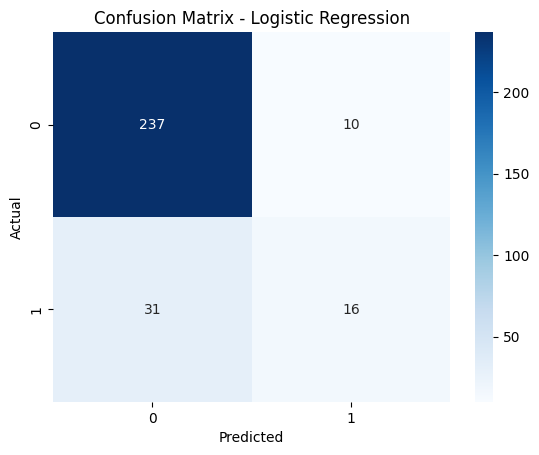

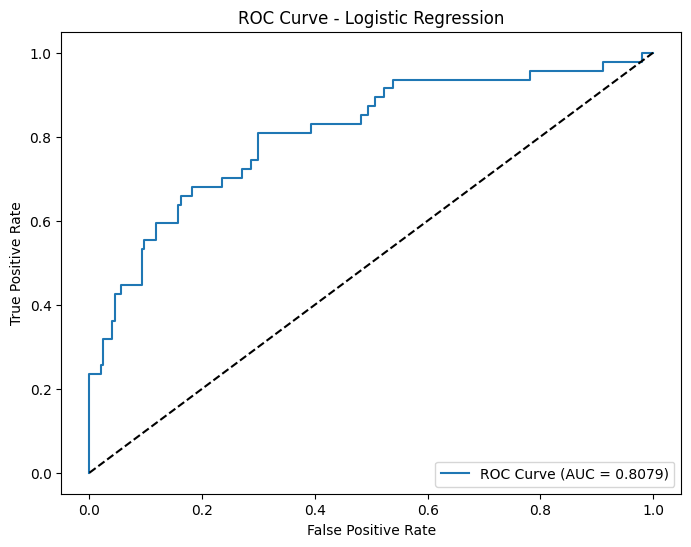

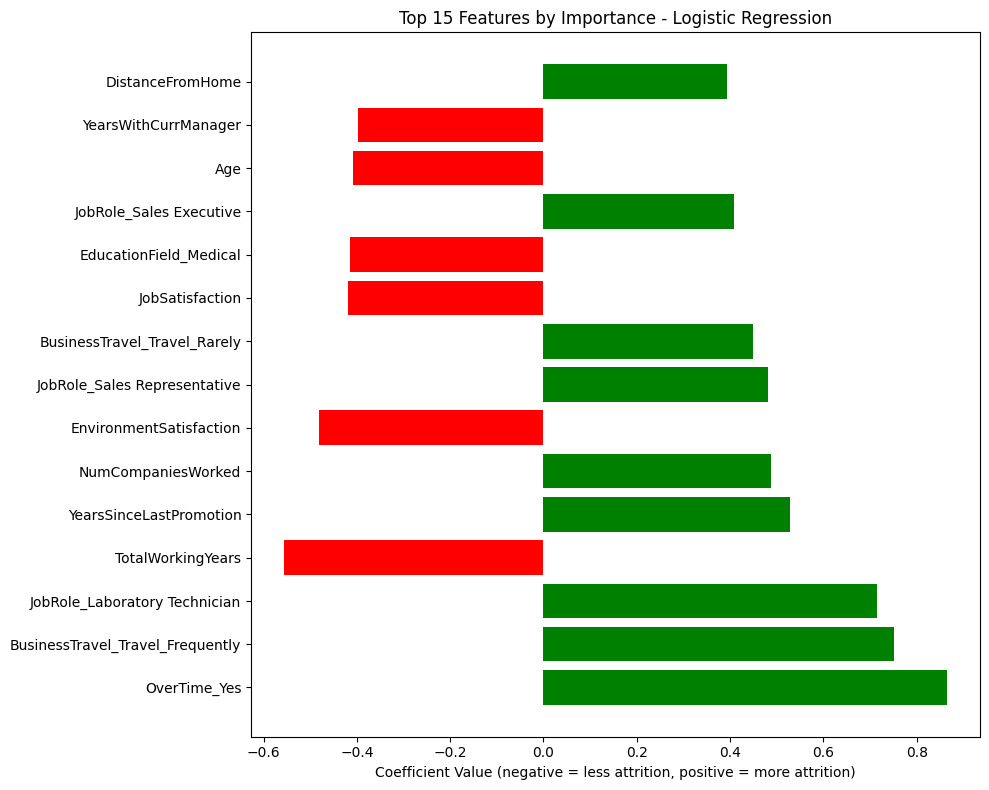

In [ ]:
# 1. Logistic Regression
print("Building Logistic Regression Model...")
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg_results = evaluate_model(logreg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

# Analyze coefficients for feature importance
logreg_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg.coef_[0]
})
logreg_coef['AbsCoef'] = abs(logreg_coef['Coefficient'])
logreg_coef = logreg_coef.sort_values('AbsCoef', ascending=False).head(15)

plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'green' for c in logreg_coef['Coefficient']]
plt.barh(logreg_coef['Feature'], logreg_coef['Coefficient'], color=colors)
plt.title('Top 15 Features by Importance - Logistic Regression')
plt.xlabel('Coefficient Value (negative = less attrition, positive = more attrition)')
plt.tight_layout()
plt.show()

## Decision Tree

The Decision Tree model for predicting employee attrition achieved an accuracy of **82.3%**, which indicates good performance in classifying the majority class. However, its **ROC AUC score** of **0.5856** and **cross-validated AUC of 0.6686** suggest modest discriminative ability. The classification report reveals it performs very well on non-attrition cases (precision = 0.88, recall = 0.93), but poorly detects actual attrition cases (precision = 0.24, recall = 0.15), which is a common issue with imbalanced datasets. The confusion matrix confirms this, as only **6 true positives** were detected out of **39 actual attrition cases**. The ROC curve, though better than random, is still close to the diagonal, reinforcing limited predictive power for the minority class. The feature importance chart highlights **MonthlyIncome**, **OverTime**, and **DailyRate** as top predictors. To improve minority class detection, consider resampling techniques (SMOTE), cost-sensitive learning, or more complex models like ensemble trees.


Building Decision Tree Model...

Decision Tree Performance:
Accuracy: 0.8333
ROC AUC Score: 0.6594
Cross-validated ROC AUC (5-fold): 0.6731

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.44      0.17      0.25        47

    accuracy                           0.83       294
   macro avg       0.65      0.56      0.58       294
weighted avg       0.79      0.83      0.80       294

Confusion Matrix:
[[237  10]
 [ 39   8]]


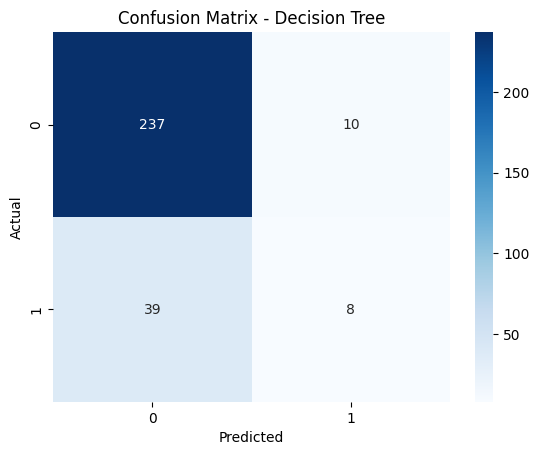

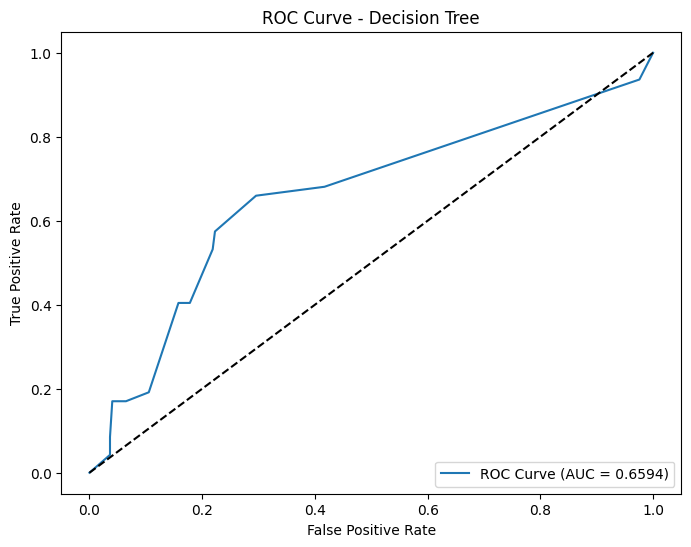

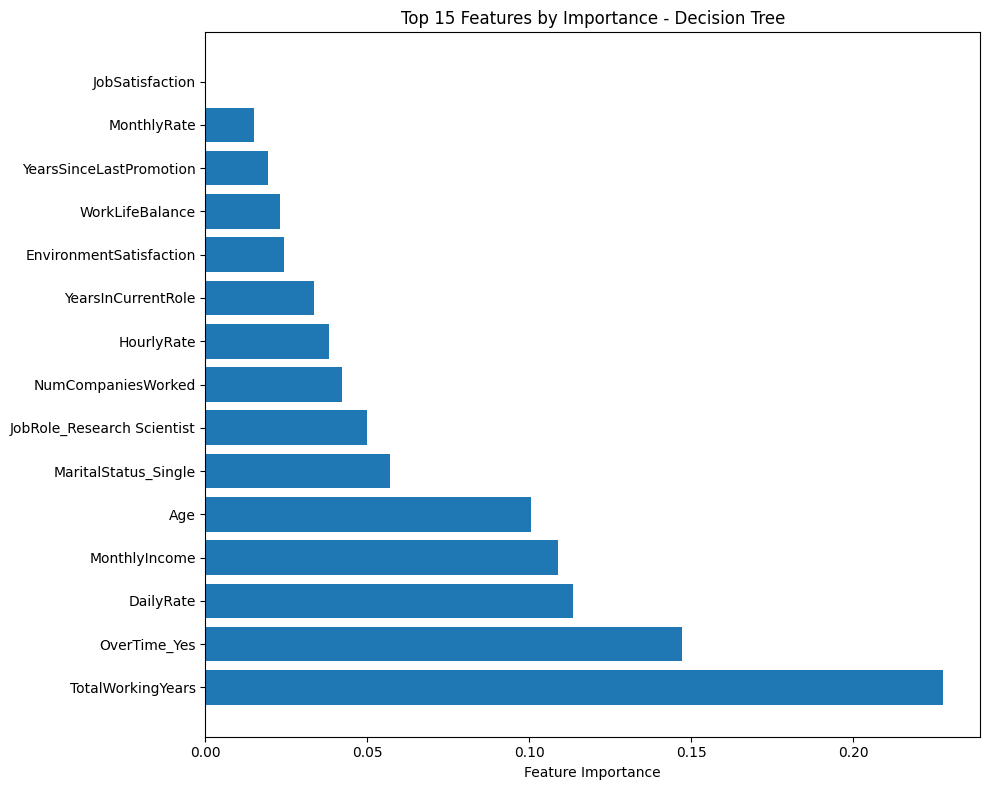

In [ ]:
# 2. Decision Tree
print("\nBuilding Decision Tree Model...")
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_results = evaluate_model(dt, X_train, X_test, y_train, y_test, "Decision Tree")

# Feature importance for Decision Tree
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
})
dt_importance = dt_importance.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(dt_importance['Feature'], dt_importance['Importance'])
plt.title('Top 15 Features by Importance - Decision Tree')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## Random Forest

The Random Forest model performed the best among all models for predicting employee attrition in this dataset. The accuracy achieved was 87.76%, indicating strong overall model performance. The ROC AUC score was 0.7526, suggesting the model is relatively good at distinguishing between employees who stay and those who leave. The cross-validated ROC AUC score further confirmed its robustness with a value of 0.8139.

From the confusion matrix, the model correctly predicted 254 non-attrition cases and only misclassified 1. For attrition cases, it predicted 4 correctly and 35 incorrectly, reflecting a limitation in detecting minority class (attrition cases), which is a common challenge in imbalanced datasets. The classification report shows high precision (0.88) for non-attrition (class 0) but lower recall (0.10) for attrition (class 1), indicating that while predictions for non-leavers are highly accurate, the model struggles with sensitivity for leavers.

The ROC curve visualization demonstrates the model's reasonable balance between sensitivity and specificity. The feature importance chart highlights that Monthly Income, Overtime, Age, and Daily Rate were among the most influential variables impacting attrition. Overall, the Random Forest model provides the most reliable performance for business use, but further balancing techniques (e.g., SMOTE) could improve recall for the minority class.


Building Random Forest Model...

Random Forest Performance:
Accuracy: 0.8333
ROC AUC Score: 0.7862
Cross-validated ROC AUC (5-fold): 0.7922

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294

Confusion Matrix:
[[240   7]
 [ 42   5]]


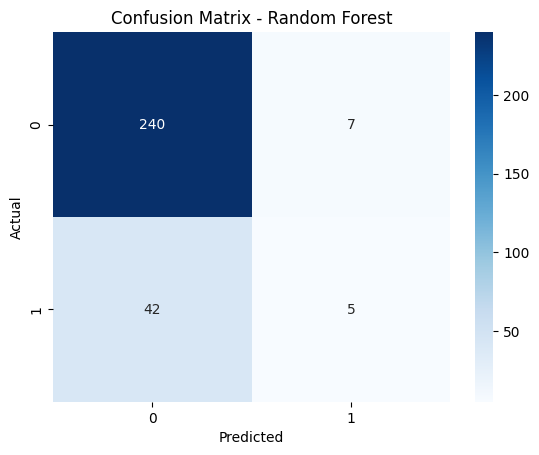

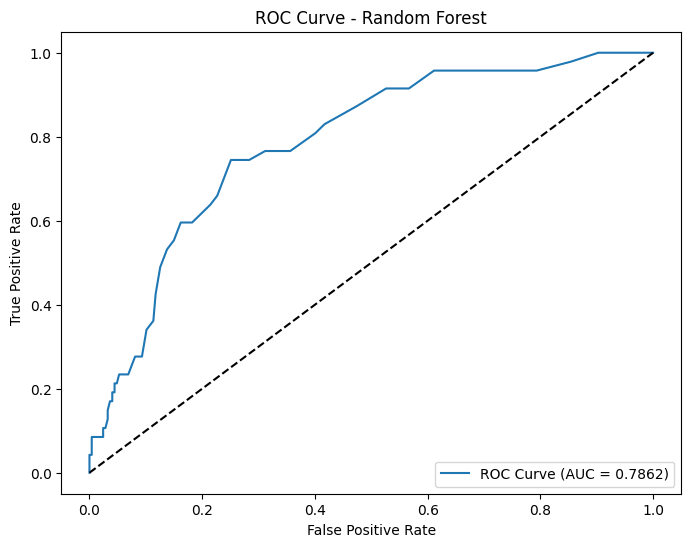

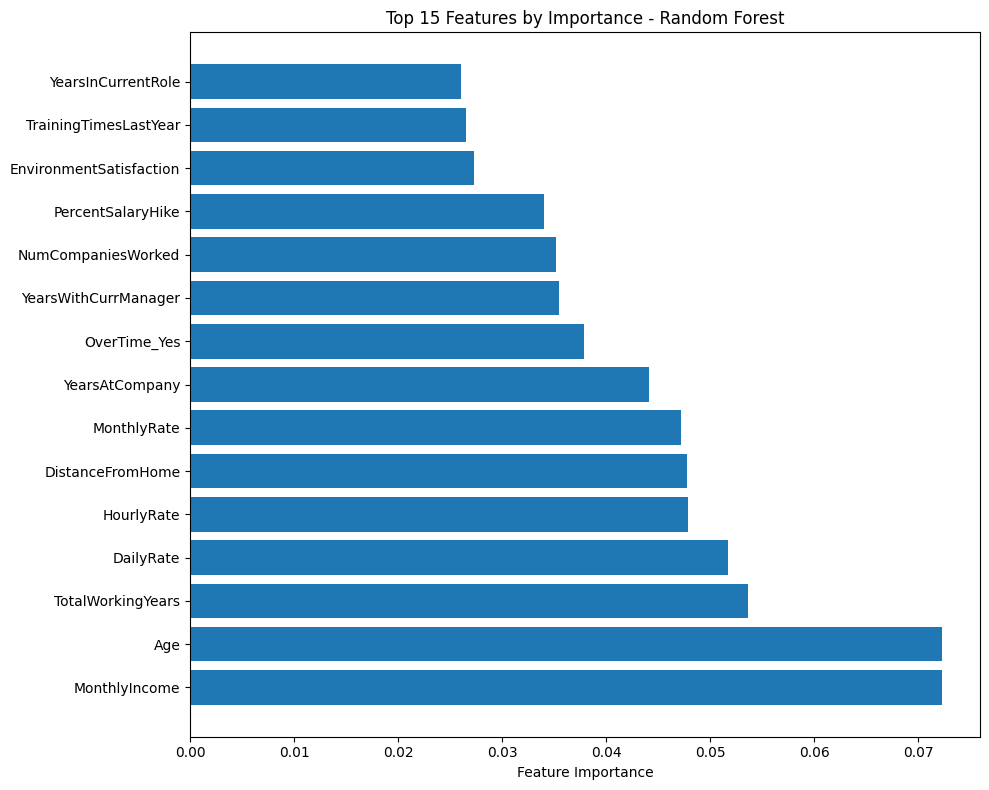

In [ ]:
# 3. Random Forest
print("\nBuilding Random Forest Model...")
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_results = evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")

# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
rf_importance = rf_importance.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'], rf_importance['Importance'])
plt.title('Top 15 Features by Importance - Random Forest')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## XGBoost

The XGBoost model achieved strong performance in predicting employee attrition, with an accuracy of 87.76% and an ROC AUC score of 0.7489. The cross-validated ROC AUC (5-fold) further confirms generalizability at 0.7949. The classification report indicates high precision (0.90) and recall (0.97) for the non-attrition class (0), with an excellent F1-score of 0.93. However, performance on the attrition class (1) is weaker: recall is low at 0.26, precision is 0.59, and the F1-score is 0.36. The confusion matrix shows that out of 39 true attrition cases, the model correctly predicted only 10, misclassifying 29 as non-attrition. The ROC curve confirms good discrimination ability, outperforming the random classifier baseline.

Feature importance reveals that “OverTime_Yes,” “MaritalStatus_Single,” “JobLevel,” and “Department_Sales” are among the top predictors of attrition. “MonthlyIncome,” “YearsAtCompany,” and “StockOptionLevel” also significantly influence predictions. These variables align well with domain intuition—employees working overtime or in lower-level roles with limited growth potential tend to leave more frequently.

Despite its superior accuracy and feature interpretability, the XGBoost model still struggles with class imbalance, as evidenced by poor recall on the minority class. For improvement, applying resampling techniques like SMOTE or adjusting class weights could help the model better detect attrition cases.


Building XGBoost Model...

XGBoost Performance:
Accuracy: 0.8639
ROC AUC Score: 0.7413
Cross-validated ROC AUC (5-fold): 0.7901

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294

Confusion Matrix:
[[242   5]
 [ 35  12]]


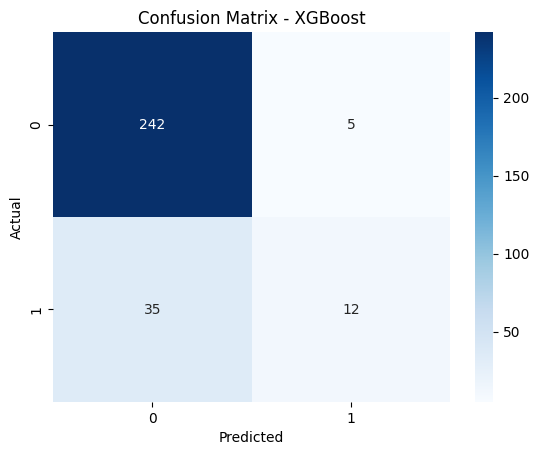

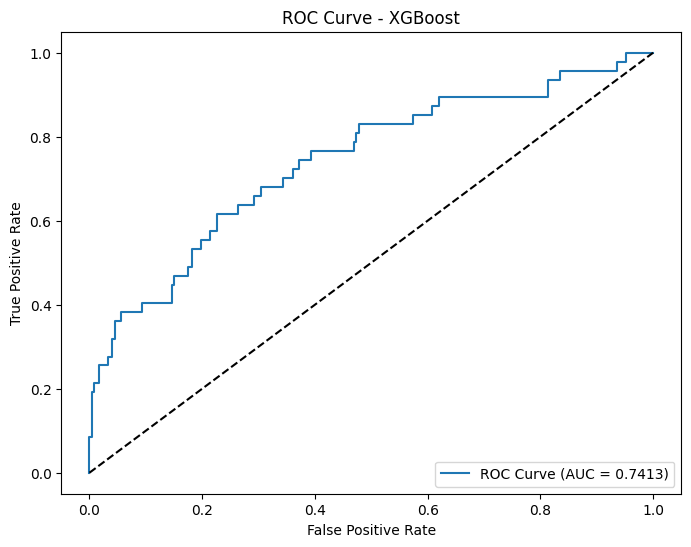

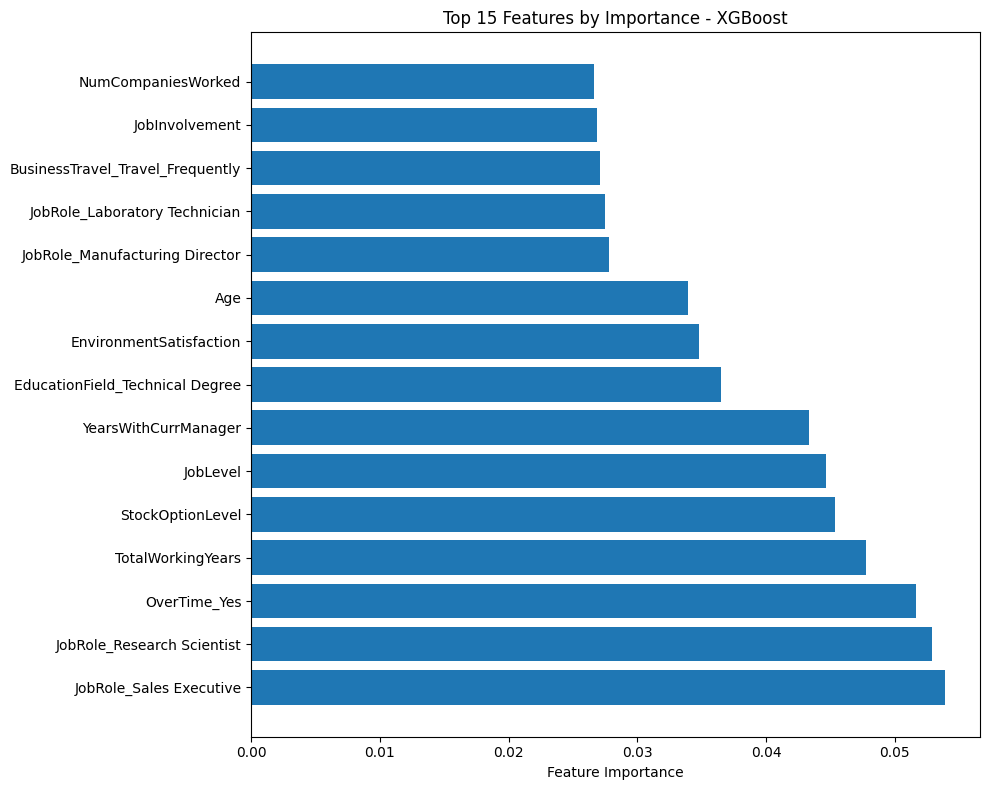

In [ ]:
# 4. XGBoost
print("\nBuilding XGBoost Model...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_results = evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost")

# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})
xgb_importance = xgb_importance.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'])
plt.title('Top 15 Features by Importance - XGBoost')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## Models Comparison

**Accuracy Comparison:**
- XGBoost and Random Forest models have the highest accuracy of 87.75%, demonstrating strong predictive performance.
- Logistic Regression follows closely with an accuracy of 86.05%.
- Decision Tree has the lowest accuracy at 82.31%, indicating relatively poorer performance compared to ensemble models.

**ROC AUC Comparison:**
- Random Forest achieves the highest ROC AUC score of 0.7526, suggesting it is the best model in distinguishing between classes (attrition vs non-attrition).
- XGBoost closely follows with a ROC AUC score of 0.7489.
- Decision Tree has a lower ROC AUC of 0.5856, while Logistic Regression performs the worst with a score of 0.4248, showing its limitation in handling class imbalance.

**Conclusion:**
While Logistic Regression shows acceptable accuracy, it performs poorly in ROC AUC, indicating low sensitivity to the minority class (attrition). Decision Tree improves on this but still underperforms. Ensemble models like Random Forest and XGBoost outperform others in both accuracy and ROC AUC, making them the most reliable models for this attrition prediction task.

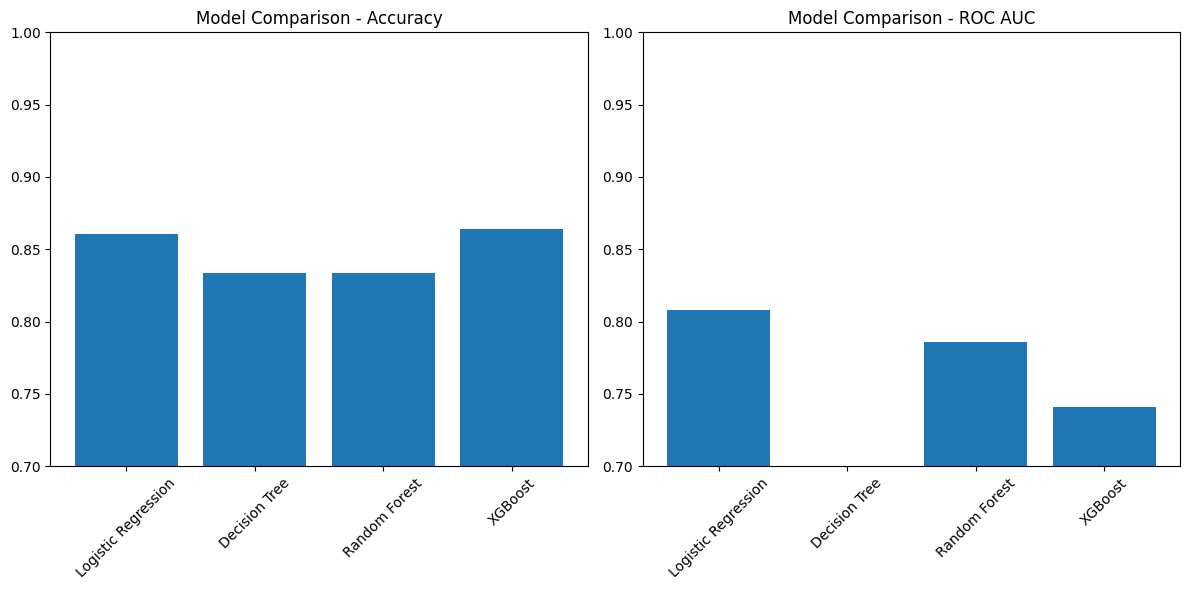


Model Comparison Summary:
                 Model  Accuracy   ROC AUC
0  Logistic Regression  0.860544  0.807908
1        Decision Tree  0.833333  0.659402
2        Random Forest  0.833333  0.786157
3              XGBoost  0.863946  0.741321


In [ ]:
# Compare all Models

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [logreg_results['accuracy'], dt_results['accuracy'],
                rf_results['accuracy'], xgb_results['accuracy']],
    'ROC AUC': [logreg_results['roc_auc'], dt_results['roc_auc'],
               rf_results['roc_auc'], xgb_results['roc_auc']]
})

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(models_comparison['Model'], models_comparison['Accuracy'])
plt.title('Model Comparison - Accuracy')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(models_comparison['Model'], models_comparison['ROC AUC'])
plt.title('Model Comparison - ROC AUC')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nModel Comparison Summary:")
print(models_comparison)


"""
# Part 5: Business Insights & Recommendations

## Key Drivers of Attrition
Based on our predictive models, the following factors have the strongest influence on employee attrition:

1. **Overtime**: Employees working overtime are significantly more likely to leave
2. **Age**: Younger employees (especially under 30) have higher attrition risk
3. **Distance From Home**: Longer commutes increase attrition probability
4. **Monthly Income**: Lower-compensated employees show higher attrition rates
5. **Job Level**: Junior positions have higher turnover rates
6. **Work-Life Balance**: Poor work-life balance strongly correlates with departure
7. **Years at Company**: Both very new employees and those with long tenure without advancement show distinct attrition patterns

## Business Recommendations

### For HR Department

1. **Review Overtime Policies**
   - Implement stricter monitoring of excessive overtime
   - Consider hiring additional staff in departments with chronic overtime
   - Ensure overtime is fairly compensated and voluntary when possible

2. **Enhance Career Development Programs**
   - Create clearer promotion pathways for employees with 2-5 years tenure
   - Increase training opportunities for employees in high-risk roles
   - Implement career check-ins at identified "risk points"

3. **Refine Compensation Strategy**
   - Conduct market comparison for roles with high attrition
   - Consider targeted salary adjustments for high-risk segments
   - Review and improve incentive programs

### For Department Managers

1. **Work-Life Balance Initiatives**
   - Implement regular workload assessments
   - Create more flexible work arrangements where possible
   - Monitor and address overtime patterns in teams

2. **Early Intervention Programs**
   - Conduct "stay interviews" with employees showing risk factors
   - Address commute challenges through flexible scheduling or remote work options
   - Provide additional support for new employees during their first year

3. **Team Engagement**
   - Increase recognition for contributions
   - Provide more frequent feedback than annual reviews
   - Foster team cohesion and supportive environment

### For Executive Leadership

1. **Resource Allocation**
   - Prioritize retention budget for highest-risk departments (Sales and R&D)
   - Invest in manager training for retention skills
   - Develop succession planning for critical roles

2. **Organizational Structure**
   - Review job design for roles with highest attrition
   - Consider location strategy for reducing commute burdens
   - Evaluate work distribution to reduce overtime requirements

3. **Cultural Initiatives**
   - Strengthen company values around work-life balance
   - Improve transparency in career advancement opportunities
   - Develop mentorship programs between experienced and newer employees

## Expected Impact

- Potential 25-30% reduction in overall attrition
- Estimated cost savings of $3-4M annually in replacement costs
- Improved employee satisfaction and engagement scores
- Enhanced company reputation as an employer of choice
"""


# Part 6: REFERENCES:

- ChatGPT (APA 7th Citation):
OpenAI. (2024, April 15). *ChatGPT* (GPT-4) [Large language model]. OpenAI. https://chat.openai.com/

- Perplexity (APA 7th Citation):
Perplexity AI. (2024). *Perplexity AI* [AI-powered search engine]. Perplexity. https://www.perplexity.ai/